#The Dual-Route Model of Induction: Demo

*Induction heads*, originally found by [Elhage et al. (2021)](https://transformer-circuits.pub/2021/framework/index.html) in their study of two-layer neural networks, are attention heads found in autoregressive transformers that are responsible for copying forward information from context. [Previous work](https://transformer-circuits.pub/2022/in-context-learning-and-induction-heads/index.html) suggested that these heads might be important for tasks beyond literal copying---but how can heads that blindly copy token-by-token be responsible for soft tasks like translation?

In our new paper, [The Dual-Route Model of Induction](https://dualroute.baulab.info/), we physically separate two types of induction heads: *token induction heads*, which have so far been the major object of study, and **a new type of head, *concept induction heads***. These two types of heads operate at the same time in parallel, independent from each other. While token induction heads are important for verbatim copying tasks, concept induction heads are used for paraphrasing, translation, and other types of "fuzzy copying."

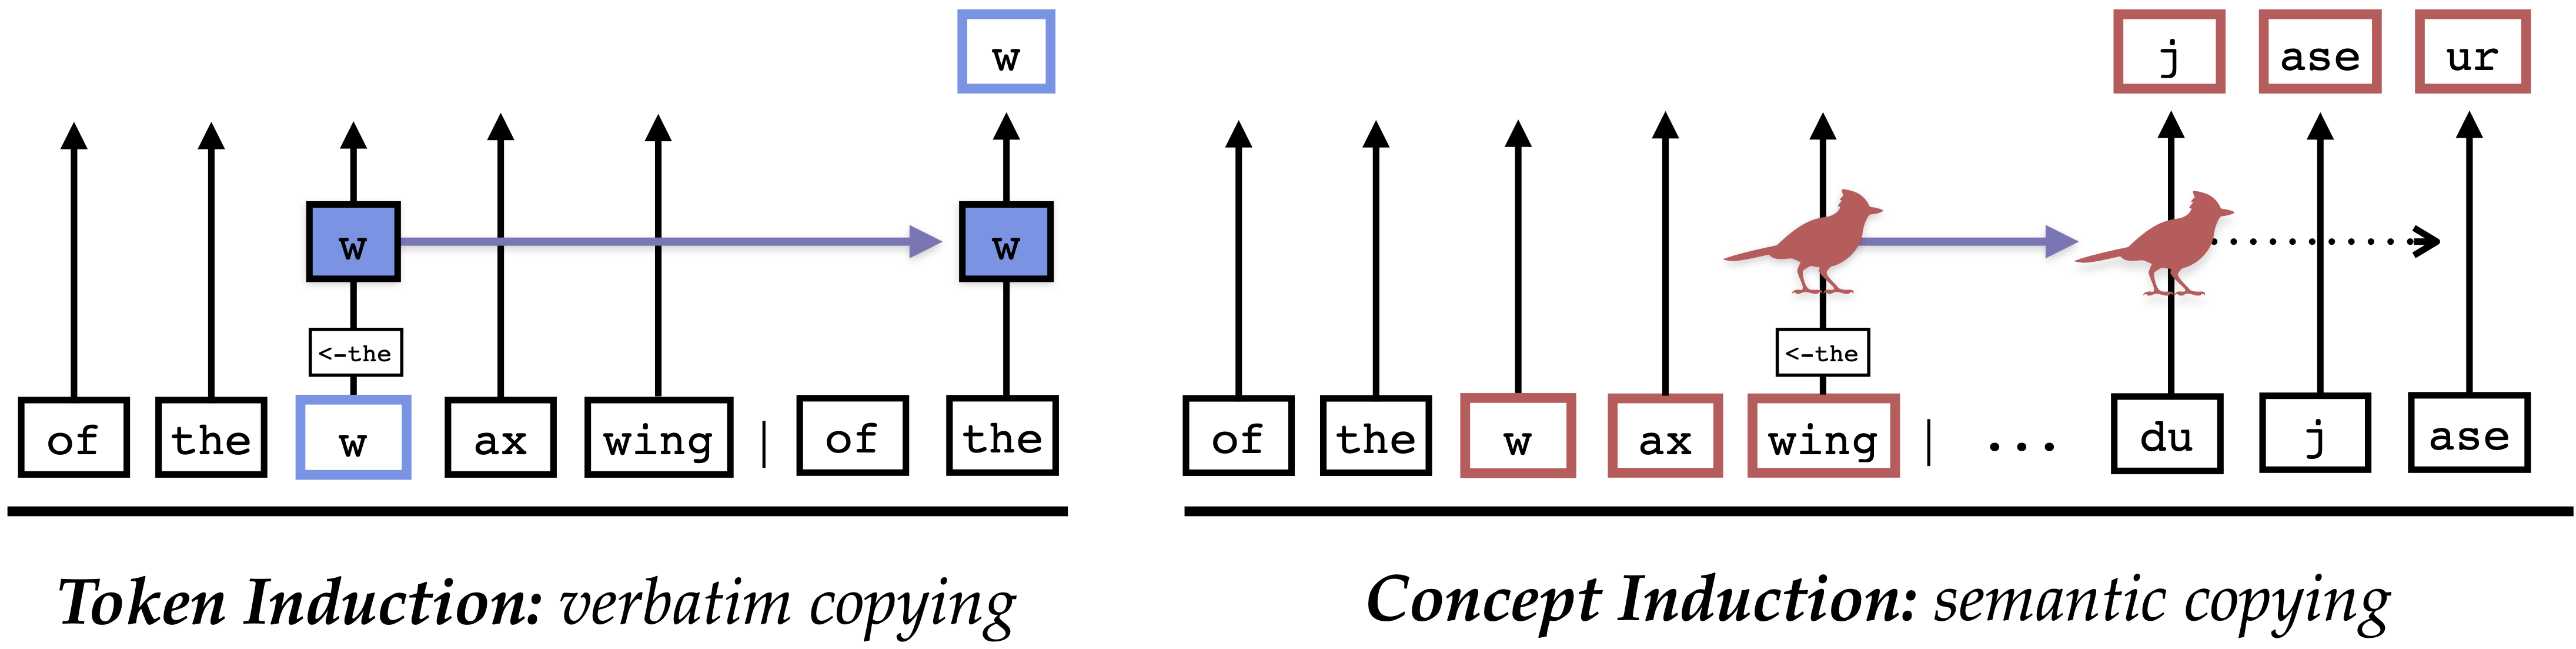

This notebook provides quick snippets of code to replicate (what we think is) our most interesting results, so that you can play around with different inputs and get a sense for our work. You can read the full paper [here](https://arxiv.org/abs/2504.03022), or check out our [paper website](https://dualroute.baulab.info/) with links to GitHub code and other information. (Please contact `feucht.s[@]northeastern.edu` if you run into any issues with this notebook, or have any questions.)

#Setup
You'll need access to the [Llama-2-7b](https://huggingface.co/meta-llama/Llama-2-7b-hf) repository to run this notebook. Additionally, we'll install `nnsight`, a package from the [NDIF project](https://ndif.us/) that will make it easy to access and manipulate model internals. Make sure you are on a GPU runtime (Runtime > Change runtime type).

It will take about 10-15 minutes to download the model for the first time.

In [6]:
from IPython.display import clear_output
!pip install nnsight
!pip install -U bitsandbytes
clear_output()

In [7]:
from huggingface_hub import notebook_login
notebook_login()

In [5]:
import torch
from nnsight import LanguageModel
from transformers import BitsAndBytesConfig
qcfg = BitsAndBytesConfig(load_in_8bit=True)
model = LanguageModel('meta-llama/Llama-2-7b-hf', device_map='cuda', dispatch=True, quantization_config=qcfg, attn_implementation='eager')

config.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.50G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/9.98G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/188 [00:00<?, ?B/s]

# (1) How do we actually find these heads?
In prior work, induction heads have been defined based on attention scores---does this head attend to the next token in a repeated random sequence? (e.g. in "five luck quickly five luck", does the head at "luck" attend to "quickly"?). In this work, we decided to find induction heads **causally**. In other words, we set up an experiment where we took the outputs of an attention head in a copying setting and patched that head into a non-copying sequence.

This process takes a long time to run, so we've omitted it from this notebook. If you'd like to see the details of how this works, read Section 2 of our paper, or take a look at `scripts/causal_scores.py` on GitHub.

***But how could activation patching possibly separate token copying heads from semantic copying heads?***

We hypothesize that if an attention head is copying over the meaning of a multi-token word (i.e., some latent vector that can be expressed in different tokens/languages), it should have information about all tokens in that word. That means it should increase the probability of *future* tokens when patched into a new context, not just the next token.

This is because of the weirdness of tokenization that we get for any LLM with a fixed vocabulary size. Many words (like "cardinals", shown below) are chopped into nonsensical bits by tokenizers, meaning that models must learn that `card` and `inals` actually map to one specific meaning. This process is known as "detokenization" ([Elhage et al., 2022](https://transformer-circuits.pub/2022/solu/index.html); [Gurnee et al., 2023](https://arxiv.org/abs/2305.01610)). But if the model wants to copy the word "cardinals," it has to convert that latent representation back into the tokens `card` and `inals`.

So, if we patch an attention head into a new sequence and it increases the probability of the next copied token, we know it is doing some type of copying. But it if *also* increases the probability of the token after that, then we hypothesize that it is carrying the entire concept! Based on our experiments in the rest of the paper, we are quite sure that this is true.  

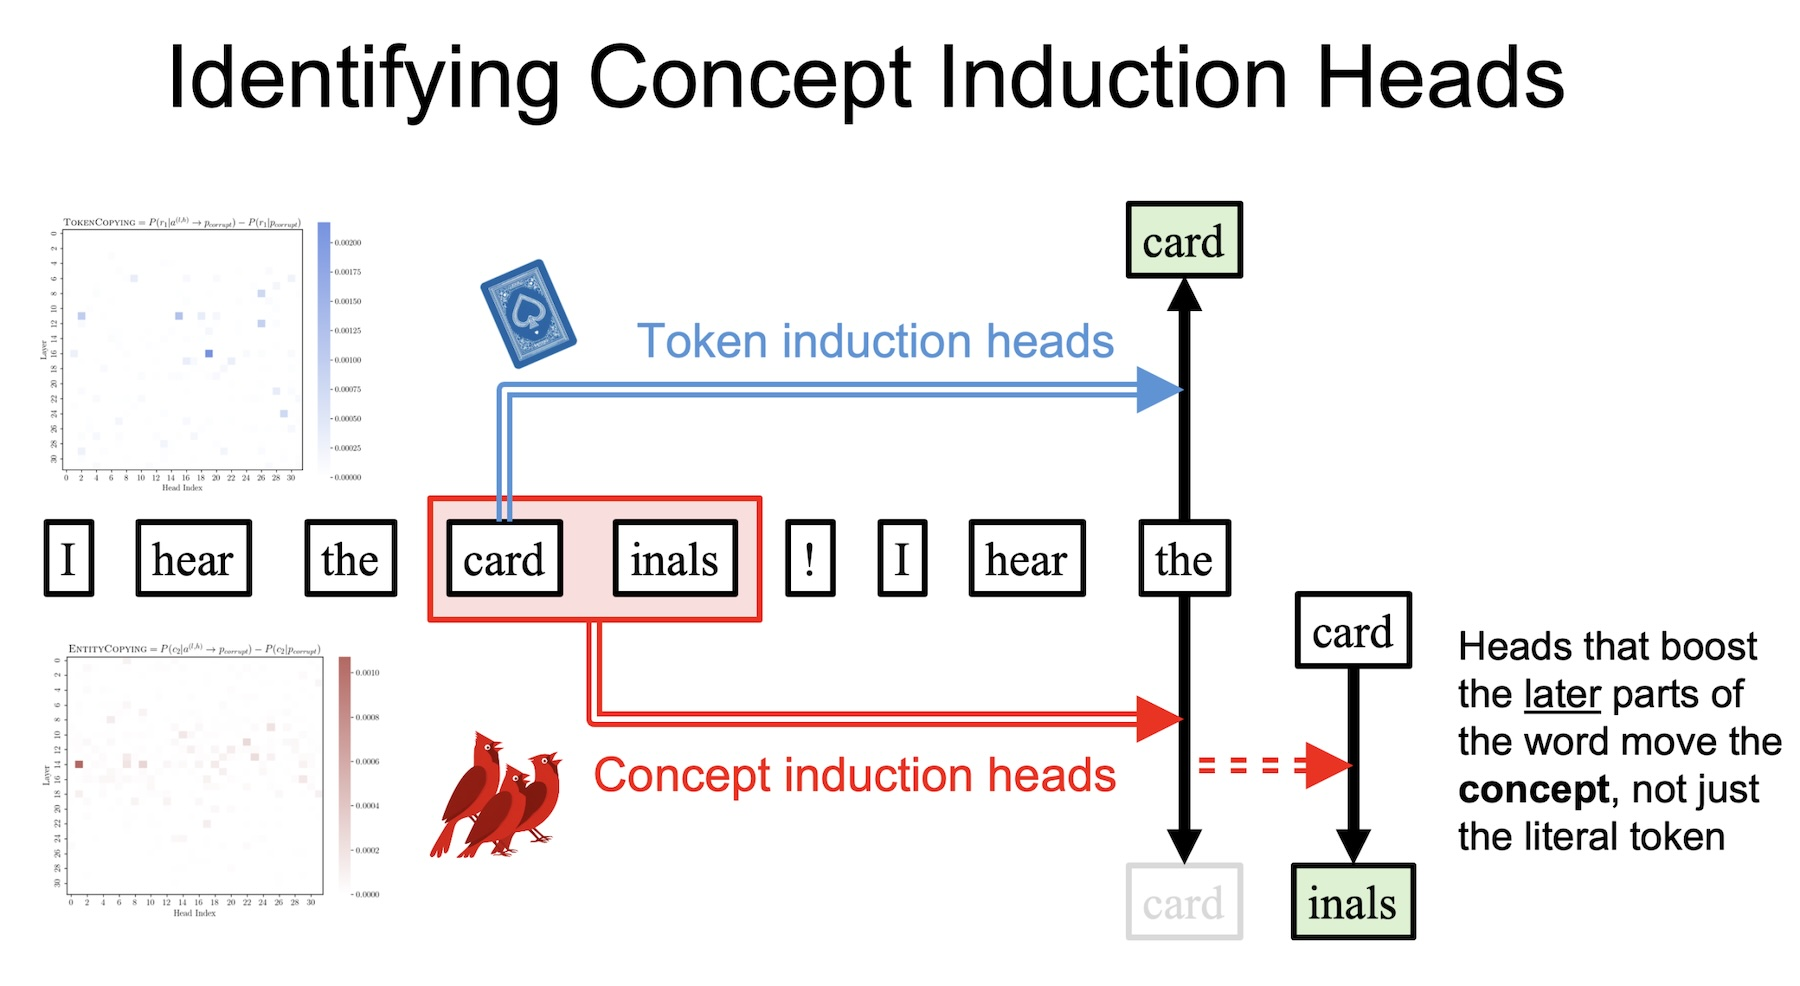

In [8]:
!git clone https://github.com/sfeucht/dual-route-induction.git

Cloning into 'dual-route-induction'...
remote: Enumerating objects: 592, done.
remote: Counting objects: 100% (592/592), done.
remote: Compressing objects: 100% (295/295), done.
remote: Total 592 (delta 313), reused 559 (delta 288), pack-reused 0 (from 0)
Receiving objects: 100% (592/592), 18.50 MiB | 8.11 MiB/s, done.
Resolving deltas: 100% (313/313), done.
Updating files: 100% (472/472), done.


In [9]:
# Loading pre-calculated concept and token scores. See repo `causal_scores.py` and paper for causal head-patching explanation.
import json
with open('dual-route-induction/cache/causal_scores/Llama-2-7b-hf/concept_copying_len30_n1024.json', 'r') as f:
  concept_scores = json.load(f)
with open('dual-route-induction/cache/causal_scores/Llama-2-7b-hf/token_copying_len30_n1024.json', 'r') as f:
  token_scores = json.load(f)

In [10]:
concept_head_ordering = [(d['layer'], d['head_idx']) for d in sorted(concept_scores, key=lambda d: d['score'], reverse=True)]
token_head_ordering = [(d['layer'], d['head_idx']) for d in sorted(token_scores, key=lambda d: d['score'], reverse=True)]

# (2) Attention Scores: Where are these heads attending?

So, we've used causal mediation to sort all attention heads in two ways: based on how much they copy the next token, and based on how much they copy the token *after* the next token. We've hypothesized that "next-next token" heads are actually copying over the entire word.

If we look at the attention scores for these "next-next token" heads, we see that they do seem to focus on the *ends* of multi-token words. This behavior is a lot like token induction heads, except over larger units.

## Code Implementation
Expand this section if you want to see how we are calculating attention weights. Here we show *value-weighted attention* (Elhage et al., 2021), which just means that attention scores are higher if the value vector they correspond to has a higher norm.

In [11]:
import math

# https://github.com/huggingface/transformers/blob/main/src/transformers/models/llama/modeling_llama.py#L178
def rotate_half(x):
    """Rotates half the hidden dims of the input."""
    x1 = x[..., : x.shape[-1] // 2]
    x2 = x[..., x.shape[-1] // 2 :]
    return torch.cat((-x2, x1), dim=-1)
def apply_rotary_pos_emb(q, k, cos, sin, position_ids=None, unsqueeze_dim=1):
    cos = cos.unsqueeze(unsqueeze_dim)
    sin = sin.unsqueeze(unsqueeze_dim)
    q_embed = (q * cos) + (rotate_half(q) * sin)
    k_embed = (k * cos) + (rotate_half(k) * sin)
    return q_embed, k_embed

# given a sequence and layer, get attention weights for all heads.
def get_l2_attn_weights(model, tokenized, layer, value_weighting=True):
    n_heads = model.config.num_attention_heads
    head_dim = model.config.hidden_size // n_heads

    with torch.no_grad(), model.trace(tokenized):
        # positional_embeddings (cos, sin) each shape [bsz, seq_len, head_dim]
        position = model.model.layers[layer].self_attn.inputs[1]['position_embeddings']
        attention_mask = model.model.layers[layer].self_attn.inputs[1]['attention_mask']

        # [bsz, seq_len, model_size]
        query_states = model.model.layers[layer].self_attn.q_proj.output
        key_states = model.model.layers[layer].self_attn.k_proj.output

        bsz = query_states.shape[0]; seq_len = query_states.shape[1]
        if value_weighting:
            # [bsz, seq_len, model_size] -> [bsz, seq_len, n_heads, head_dim]
            value_states = model.model.layers[layer].self_attn.v_proj.output
            value_states = value_states.view(bsz, seq_len, n_heads, head_dim).save()

        # from modeling_llama, convert to [bsz, n_heads, seq_len, head_dim] and rotate
        query_states = query_states.view(bsz, seq_len, -1, head_dim).transpose(1, 2)
        key_states = key_states.view(bsz, seq_len, -1, head_dim).transpose(1, 2)
        query_states, key_states = apply_rotary_pos_emb(query_states, key_states, position[0], position[1])

        # not needed because num_key_value_heads == num_attention_heads
        # key_states = repeat_kv(key_states, self.num_key_value_groups)
        attn_weights = torch.matmul(query_states, key_states.transpose(2, 3)) / math.sqrt(head_dim)

        # has to be eager implementation
        causal_mask = attention_mask[:, :, :, : key_states.shape[-2]]
        attn_weights = attn_weights + causal_mask
        attn_weights = attn_weights.save()

    if not value_weighting:
        return attn_weights.softmax(dim=-1).detach().cpu()
    else:
        # get l2 norm of each head value vector [bsz, seq_len, n_heads] -> [bsz, n_heads, seq_len]
        value_norms = torch.linalg.vector_norm(value_states, dim=-1).detach().cpu().transpose(1, 2)

        # attn_weights [bsz, n_heads, seq_len, seq_len]
        attn_weights = attn_weights.softmax(dim=-1).detach().cpu()

        # then multiply by softmax values and normalize
        effective = attn_weights * value_norms.unsqueeze(2).expand(attn_weights.shape)
        effective /= torch.sum(effective, dim=-1, keepdim=True)
        return effective

In [12]:
from matplotlib.colors import LinearSegmentedColormap
concept_cmap = LinearSegmentedColormap.from_list('concept_cmap', (
    # Edit this gradient at https://eltos.github.io/gradient/#FFFFFF-BF6360
    (0.000, (1.000, 1.000, 1.000)),
    (1.000, (0.749, 0.388, 0.376))))

token_cmap = LinearSegmentedColormap.from_list('token_cmap', (
    # Edit this gradient at https://eltos.github.io/gradient/#FFFFFF-6F94E6
    (0.000, (1.000, 1.000, 1.000)),
    (1.000, (0.435, 0.580, 0.902))))

In [13]:
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

def head_set_vis(model, heads_to_show, prompt, fromtok=-2, title=""):
    prompt = model.tokenizer(f"{prompt}\n{prompt}")['input_ids']
    if "Concept" in title:
      cmap = concept_cmap
    elif "Token" in title:
      cmap = token_cmap
    else:
      cmap = "Purples"

    grid = []
    for layer, head_idx in heads_to_show:
        grid.append(
            get_l2_attn_weights(model, prompt, layer).squeeze()[head_idx, fromtok].squeeze()
        )
    grid = torch.stack(grid)

    tokenized_labels = [f'{model.tokenizer.decode(t)}' for i, t in enumerate(prompt)][:fromtok+1]
    lookup = dict(enumerate(tokenized_labels))
    plt.figure(figsize=(5, 3))
    hm = sns.heatmap(grid[:, :fromtok+1], square=True, cmap=cmap)
    plt.xticks(range(len(tokenized_labels)), tokenized_labels, rotation='vertical')
    plt.yticks(range(grid.shape[0]), [f'{h[0]}.{h[1]}' for h in heads_to_show], rotation='horizontal')

    x_positions = hm.get_xticks()
    y_positions = hm.get_yticks()
    x_labels = hm.get_xticklabels()
    y_labels = hm.get_yticklabels()

    # Shift ticks to center of cells
    hm.set_xticks([x + 0.5 for x in range(grid[:, :fromtok+1].shape[1])])
    hm.set_xticklabels(x_labels)
    hm.set_yticks([y + 0.5 for y in range(grid.shape[0])])
    hm.set_yticklabels(y_labels)

    ax = plt.gca()
    for _, spine in ax.spines.items():
        spine.set_visible(True)
        spine.set_linewidth(1)
        spine.set_color('black')

    plt.title(f'Llama-2-7b: Top-{k} {title}')
    plt.tight_layout()
    plt.show()

## Interactive Visualization

We've created two figures: one that shows token head attention patterns over a copied sequence, and another that shows concept head attention patterns. **Token heads mostly attend to the next *token* to be copied, `window`, whereas concept heads attend a little further ahead, to the end of the word "windowpane".** Try a different copied sequence by changing `prompt`.

You're using a LlamaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


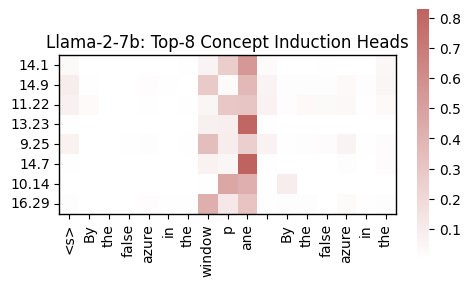

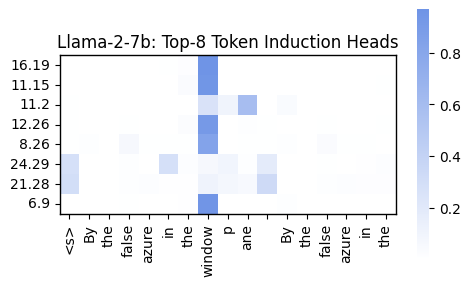

In [14]:
# visualize the top-8 concept heads and token head attention patterns
k = 8; prompt = "By the false azure in the windowpane"
head_set_vis(model, concept_head_ordering[:k], prompt, fromtok=-4, title="Concept Induction Heads")
head_set_vis(model, token_head_ordering[:k], prompt, fromtok=-4, title="Token Induction Heads")

# (3) Concept/Token Lens: What information are these heads actually transferring?

Now, we have a bunch of heads that promote future tokens and have induction-like attention patterns. Can we actually look at what these heads are actually reading out from the residual stream? By combining the weights of the top-$k$ concept or token induction heads, we can create a *concept lens* to directly project semantic information from hidden states into token space. In other words, **using concept head weights, we can take a hidden state from the model at any point and see what kind of semantics are currently represented in that state.**

## Code Implementation
Expand this section if you want to see exactly how we get our *concept lens*. For each concept induction head, we take its value and output projection matrices and multiply them together to get that attention head's OV matrix ([Elhage et al., 2021](https://transformer-circuits.pub/2021/framework/index.html)). We then sum the top-$k$ OV matrices, with $k=80$ based on other experiments from the paper. This gives us a matrix of shape (`model_dim`, `model_dim`) that we can use to transform any hidden state before we project it to vocabulary space using logit lens ([nostalgebraist, 2020](https://www.lesswrong.com/posts/AcKRB8wDpdaN6v6ru/interpreting-gpt-the-logit-lens)).

The key idea here is that an attention head's value projection determines what information it reads out of the residual stream, whereas its output projection determines how it writes that information back in. By summing all of these matrices, we can simulate what the outputs of our concept heads would be if we forced them all to attend to a hidden state at a particular layer. (See Appendix E of our paper for more explanation/intuition on why we expect this to work.)

Note: if you want to run this for models with grouped query attention (GQA), check our GitHub implementation.

In [15]:
# workaround for notebook: get full-precision llama-2-7b weight matrices on CPU
from transformers import AutoModelForCausalLM

cpu_model = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-2-7b-hf",
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True,
    device_map={"": "cpu"}  # load weights on CPU only
)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [16]:
import os
from matplotlib import font_manager

# apply lm head to a model_dim hidden state
def logit_lens(concept_vec, model, k=10):
    with torch.no_grad():
        concept_vec = concept_vec.to(model.lm_head.weight.dtype)
        logits = model.lm_head(model.model.norm(concept_vec.cuda()))
        return torch.topk(logits.softmax(dim=-1).cpu(), k=k)

# calculate sum of some set of attention head OV matrices
def get_ov_sum(model, k, head_ordering='concept'):
    model_name = model.config._name_or_path.split('/')[-1]
    model_dim = model.config.hidden_size
    head_dim = model_dim // model.config.num_attention_heads

    if head_ordering == 'all':
        to_sum = [(l, h) for l in range(model.config.num_hidden_layers) for h in range(model.config.num_attention_heads)]
    else:
        with open(f'dual-route-induction/cache/causal_scores/{model_name}/{head_ordering}_copying_len30_n1024.json', 'r') as f:
            temp = json.load(f)
        tups = sorted([(d['layer'], d['head_idx'], d['score']) for d in temp], key=lambda t: t[2], reverse=True)
        to_sum = [(l, h) for l, h, _ in tups][:k]
    layerset = set([l for l, _ in to_sum])

    with torch.no_grad():
        ov_sum = torch.zeros((model_dim, model_dim), device='cuda')
        for layer in layerset:
            for l, h in to_sum:
                if l == layer:
                    this_attn = cpu_model.model.layers[l].self_attn
                    v_proj = this_attn.v_proj.weight
                    o_proj = this_attn.o_proj.weight

                    # (out_features, in_features).
                    V = v_proj[h * head_dim : (h+1) * head_dim].cuda() # select rows so that (128, 4096) projects hidden state down.
                    O = o_proj[:, h * head_dim : (h+1) * head_dim].cuda() # select columns so that (4096, 128) converts value back up
                    ov_sum += torch.matmul(O, V) # 4096, 4096
        return ov_sum

# given a concept string w project hidden state from layer_idx/offset using summed OV matrices
def proj_onto_ov(w, ov_sum, model, layer_idx, offset=-1, head_ordering='concept', k=80):
    with torch.no_grad(), model.trace(w):
        state = model.model.layers[layer_idx].output[0].squeeze()[offset].detach().save()
    state = state.to(ov_sum.dtype)
    return torch.matmul(ov_sum, state), state

def ov_lens(w, model, k=80, head_ordering='concept', print_k=5, offset=-1, raw=False):
    cmap = {
        'concept' : 'Reds',
        'token' : 'Blues',
        'all' : 'Purples'
    }[head_ordering]

    to_print = [model.tokenizer.decode(t) for t in model.tokenizer(w)['input_ids']]
    if 'llama' in model.config._name_or_path:
        to_print = to_print[1:]

    # get the actual sum of OV matrices we'll be using
    ov_sum = get_ov_sum(model, k, head_ordering)

    probss, idxss = [], []
    for layer_idx in range(0, model.config.num_hidden_layers):
        projd, original = proj_onto_ov(w, ov_sum, model, layer_idx, offset, head_ordering, k)

        if raw:
            probs, idxs = logit_lens(original, model, k=print_k)
        else:
            probs, idxs = logit_lens(projd, model, k=print_k)

        probss.append(probs)
        idxss.append([model.tokenizer.decode(t) for t in idxs])

    _, ax = plt.subplots(figsize=(10,10))
    sns.heatmap(probss, annot=idxss, fmt='', ax=ax, vmin=0, vmax=1.0, cmap=cmap)
    title = str(to_print) + f' - lens({to_print[offset]})'
    if raw:
        title = f'Top-{print_k} Raw Logit Lens Outputs\n' + title
    else:
        title = f'Top-{print_k} {head_ordering.title()} Lens Outputs\n' + title
    plt.title(title)
    plt.xlabel('Top Ranked Tokens (Higher->Lower)')
    plt.ylabel('Layer')
    plt.show()

## Concept Lens: Interactive Visualization
Here, we've shown concept lens outputs for the word `card.inals` in the context of birds. Try uncommenting some other sequences to see how the model represents "cardinals" in different contexts. You can also pass in a different token `offset` to examine other words, or input your own sentence.

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 40165 (\N{CJK UNIFIED IDEOGRAPH-9CE5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


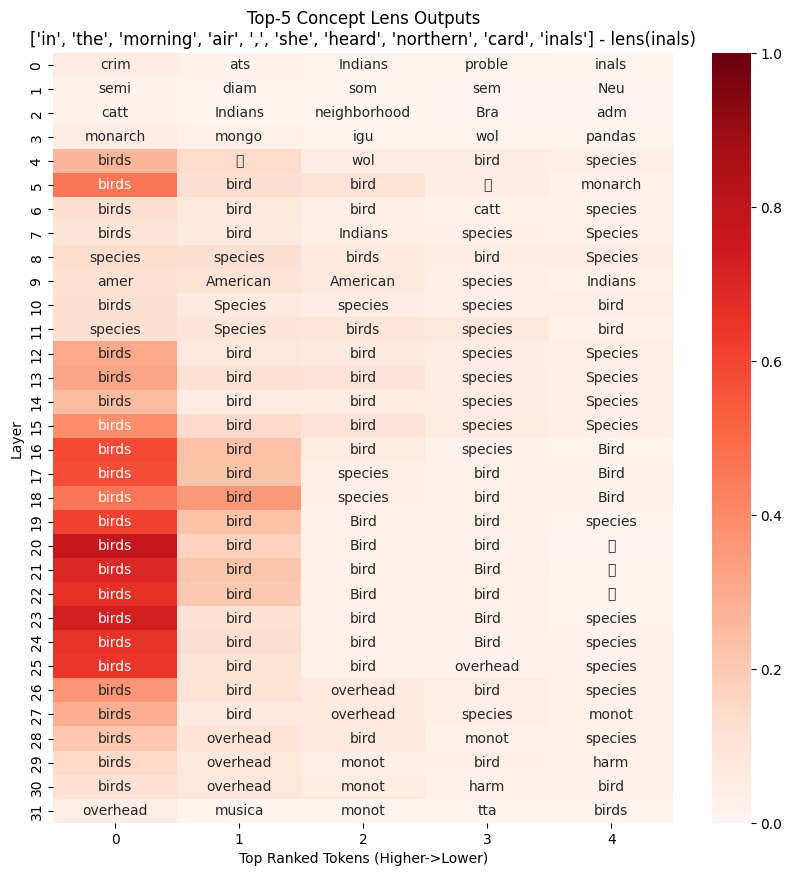

In [17]:
ov_lens('in the morning air, she heard northern cardinals', model, head_ordering='concept')
# ov_lens('the secret meeting of the cardinals', model, head_ordering='concept')
# ov_lens('he was a lifelong fan of the cardinals', model, head_ordering='concept')

## Token Lens: Interactive Visualization
You can do the same thing for token induction heads as well! Taking the top $k$ token heads lets us read out token-level information about a hidden state, instead of semantic info. Note that this is unreliable for the ends of multi-token words, as we observed in [previous work](https://footprints.baulab.info/), so we set the `offset` to -2 so that we could look at the token lens for `card` (instead of `inals`).

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 29255 (\N{CJK UNIFIED IDEOGRAPH-7247}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10134 (\N{HEAVY MINUS SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


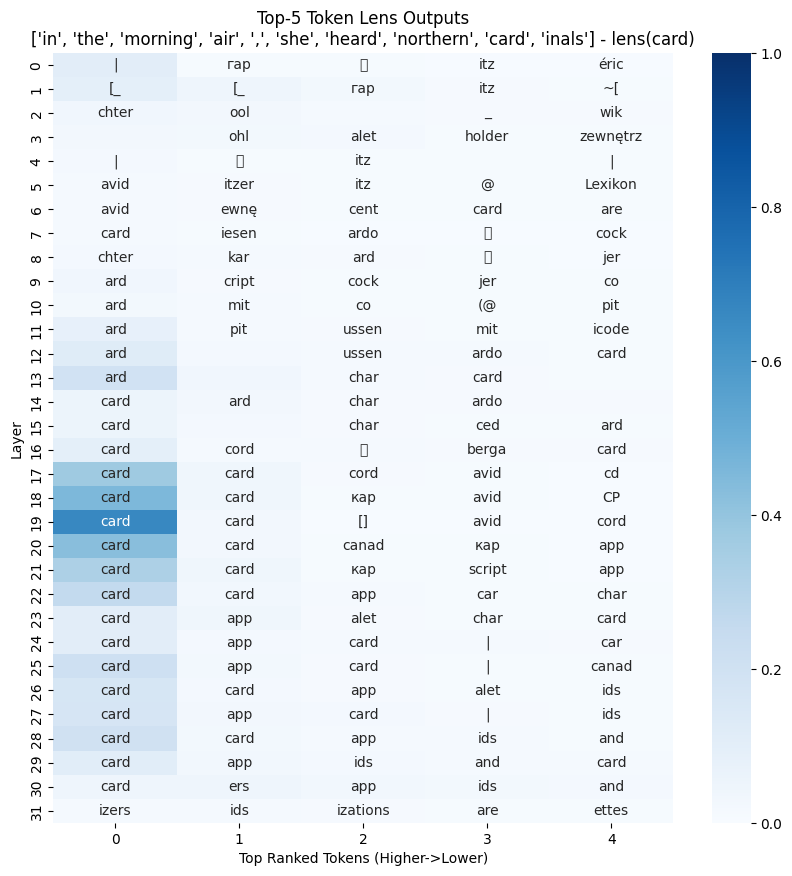

In [18]:
ov_lens('in the morning air, she heard northern cardinals', model, head_ordering='token', offset=-2)

# (4) What happens when you ablate token heads?

In Section 4 of our paper, we find that if you mean-ablate enough concept heads, models stop being able to do translation (but are still able to do verbatim copying). On the other hand, **if you mean-ablate token induction heads, models can still copy meaningful text, but they can't copy verbatim anymore; they paraphrase instead**. Here's some code that lets you play around with this phenomenon.

## Code Implementation

Expand to see code that generates tokens while ablating a given set of heads at every step.

In [72]:
def get_mean_head_values(model_name):
    dir = f'dual-route-induction/activations/{model_name}_pile-10k/'
    return torch.load(dir + 'mean.ckpt')

def ablated_generation(model, sequences, heads_to_ablate, head_means, max_toks=10):
    n_heads = model.config.num_attention_heads
    head_dim = model.config.hidden_size // n_heads

    layers_in_order = sorted(list(set([layer for layer, _ in heads_to_ablate])))

    with torch.no_grad():
        with model.generate(sequences, max_new_tokens=max_toks):
            model.all()
            for curr_layer in layers_in_order:
                o_proj = model.model.layers[curr_layer].self_attn.o_proj
                o_proj_inp = o_proj.inputs[0][0] # [bsz, seq_len, model_dim]

                # get activations for the last token [model_dim], and then
                # reshape into heads [bsz, seq_len, model_dim] -> [bsz, seq_len, n_heads, head_dim=128]
                bsz = o_proj_inp.shape[0]; seq_len = o_proj_inp.shape[1]
                head_acts = o_proj_inp.view(bsz, seq_len, n_heads, head_dim)

                curr_heads = [head for layer, head in heads_to_ablate if layer == curr_layer]
                for h in curr_heads:
                    the_mean = head_means[curr_layer, h]
                    head_acts[:, :, h, :] = the_mean.cuda()

                # replace the output of self_attn.q_proj with modified vector
                new_guy = ((head_acts.reshape(bsz, seq_len, model.config.hidden_size),),{})
                o_proj.inputs = new_guy

            out = model.generator.output.save()

        return out.detach().cpu()

def ablated_token_generation(prompt, heads_to_ablate, head_means, repeat_cutoff=1, repeated_ratio=1.3):
    bos = model.tokenizer.bos_token_id
    newline = model.tokenizer('\n')['input_ids'][-1]
    custom_chunk = model.tokenizer(prompt)['input_ids'][1:]
    copy_prompt = [bos] + custom_chunk + [newline] + custom_chunk + [newline] + custom_chunk[:repeat_cutoff]
    copy_paragraph = [copy_prompt]
    generated = ablated_generation(model, copy_paragraph, heads_to_ablate, head_means, max_toks=math.floor(len(custom_chunk)*repeated_ratio))
    print('Prompt:')
    print(model.tokenizer.decode(copy_prompt))
    print('Generated:')
    print(model.tokenizer.decode(generated[0][len(copy_prompt):]))
    print()

In [30]:
from transformers.utils import logging
logging.set_verbosity_error()

## Paraphrasing a sentence
If we generate text from the model with its top-32 token induction heads ablated, it stops copying exactly, and starts to paraphrase. If you want to convince yourself that the model *could* copy perfectly in the first place, uncomment the middle line. To get this paraphrasing effect, we have to repeat the original prompt twice---otherwise, it will not even try to copy at all once the token heads are gone.

In [20]:
head_means = get_mean_head_values('Llama-2-7b-hf')

In [83]:
torch.manual_seed(8)
prompt = "I have reread, not without pleasure, my comments to his lines, and in many cases have caught myself borrowing a kind of opalescent light from my poet's fiery orb"

# uncomment to make sure that the model actually copies when you don't ablate anything
# ablated_token_generation(prompt, [], head_means)

k = 32 # ablate the top 32 heads
ablated_token_generation(prompt, token_head_ordering[:k], head_means)

Prompt:
<s> I have reread, not without pleasure, my comments to his lines, and in many cases have caught myself borrowing a kind of opalescent light from my poet's fiery orb
 I have reread, not without pleasure, my comments to his lines, and in many cases have caught myself borrowing a kind of opalescent light from my poet's fiery orb
 I
Generated:
have reread my comments on his poems, and often found myself using a sort of opalescent light from my own poet's fiery orb.
I have reread my comments on his poems, and often caught myself using a



## Paraphrasing a piece of code

Same thing for when the model is trying to copy a snippet of code. Without token induction heads, the model "paraphrases" the code--i.e., it copieds the same meaning as the original snippet, except using list comprehension.

In [86]:
torch.manual_seed(8)
prompt = """foo = []
for i in range(len(bar)):
    if i % 2 == 0:
        foo.append(bar[i])
"""
# when you ablate no heads, make sure it actually copies.
# ablated_token_generation(prompt, [], head_means)

k = 32 # ablate top 32 heads
ablated_token_generation(prompt, token_head_ordering[:k], head_means)

Prompt:
<s> foo = []
for i in range(len(bar)):
    if i % 2 == 0:
        foo.append(bar[i])

 foo = []
for i in range(len(bar)):
    if i % 2 == 0:
        foo.append(bar[i])

 foo
Generated:
= [bar[i] for i in range(len(bar)) if i % 2 == 0]

print(foo)

foo = [bar[i] for i in range(len



# (5) Language-Invariant Conceptual Representations

Are the semantic representations carried by concept heads sensitive to input or output language? To test this, we take the outputs of the top-$k$ concept induction heads in one translation context and patch these outputs into another context. For example, we could replace the outputs of concept induction heads for a Spanish-Italian translation prompt (bottom) with their activations for a separate Japanese-Chinese setting. Where the model would have originally output "cloud" in Italian, it now outputs "boat" (the word from the Japanese-Chinese context) in Italian!

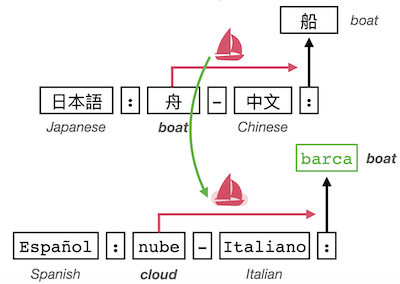


These results suggest that concept induction heads are carrying representations of words that are disentangled from input/output language. We use the same setup as [Dumas et al. (2025)](https://arxiv.org/abs/2411.08745), who originally showed that this could be done by taking a mean over word representations from different languages. It seems that concept induction heads work with the same language-agnostic representations that they found.

(Disclaimer: "language-invariant" is a strong claim, as clearly this will depend on how much exposure a model has had to a language. Models may map high-resource languages to a shared semantic space, but we have not yet tested on low-resource ones.)

## Code Implementation
Expand to see code that saves the outputs of a set of heads, as well as code that generates new text with head activations substituted.

In [59]:
import nnsight

def raw_head_activations(head, tokens, model):
    assert type(tokens[0]) == int
    bsz = 1

    layer, head_idx = head
    n_heads = model.config.num_attention_heads; head_dim = model.config.hidden_size // n_heads
    o_proj = model.model.layers[layer].self_attn.o_proj

    with torch.no_grad(), model.trace(tokens):
        o_proj_in = o_proj.input
        attn_out = o_proj_in.reshape(bsz, -1, n_heads, head_dim) #(bsz, seq_len, n_heads, head_dim)
        head_acts = attn_out[:, :, head_idx, :].detach().save()

    return head_acts

# get the activations of a bunch of heads
def source_head_activations(model, source_sequences, heads_to_grab):
    all_acts = {}
    for head in heads_to_grab:
        all_acts[tuple(head)] = raw_head_activations(head, source_sequences, model)
    return all_acts # a dict of (bsz, seq_len, head_dim) guys

# replace heads and generate accordingly
def subbed_generation(model, this_sequences, heads_to_sub, source_run_dict, max_toks=10):
    n_heads = model.config.num_attention_heads
    head_dim = model.config.hidden_size // n_heads

    layers_in_order = sorted(list(set([layer for layer, _ in heads_to_sub])))

    with torch.no_grad():
        with model.generate(this_sequences, max_new_tokens=max_toks):
            generated = nnsight.list().save()
            model.all()
            for curr_layer in layers_in_order:
                if 'pythia' in model.config._name_or_path:
                    o_proj =  model.gpt_neox.layers[curr_layer].attention.dense
                else:
                    o_proj = model.model.layers[curr_layer].self_attn.o_proj

                # [bsz, seq_len, model_dim]
                o_proj_inp = o_proj.inputs[0][0]

                # get activations for the last token [model_dim], and then
                # reshape into heads [bsz, seq_len, model_dim] -> [bsz, seq_len, n_heads, head_dim=128]
                bsz = o_proj_inp.shape[0]; seq_len = o_proj_inp.shape[1]
                head_acts = o_proj_inp.view(bsz, seq_len, n_heads, head_dim)

                curr_heads = [head for layer, head in heads_to_sub if layer == curr_layer]
                for h in curr_heads:
                    head_acts[:, -1, h, :] = source_run_dict[(curr_layer, h)][:, -1, :].cuda()

                # replace the output of self_attn.q_proj with modified vector
                new_guy = ((head_acts.reshape(bsz, seq_len, model.config.hidden_size),),{})
                o_proj.inputs = new_guy

            generated.append(model.output.logits[:, -1])
            out = model.generator.output.save()

        generated = torch.stack(generated).argmax(dim=-1).squeeze()
        return generated, out

## Patching Results
We can set up the exact patching experiment that we showed in the figure above: Japanese-Chinese translation of "boat" patched into Spanish-Italian translation of "cloud." And

In [61]:
source_prompt = """日本語: "監獄" - 中文: "监狱"
日本語: "指輪" - 中文: "指環"
日本語: "喉" - 中文: "咽头"
日本語: "ボールペン" - 中文: "圆珠笔"
日本語: "顎" - 中文: "颔"
日本語: "舟" - 中文: "
""".strip() # last line says: Japanese: "boat" - Chinese: "

base_prompt = """Español: "lápiz" - Italiano: "matita"
Español: "barbilla" - Italiano: "mento"
Español: "tenedor" - Italiano: "crocevia"
Español: "ladrillo" - Italiano: "mattone"
Español: "cajas" - Italiano: "scatola"
Español: "nube" - Italiano: "
""".strip() # last line says: Spanish: "cloud" - Italian: "

In [62]:
# normally when you prompt the model to complete this sequence, it outputs "nuvola", which is "cloud" in Italian.
with model.generate(base_prompt, max_new_tokens=3):
  output = model.generator.output.save()
print(model.tokenizer.decode(output[0]))

<s> Español: "lápiz" - Italiano: "matita"
Español: "barbilla" - Italiano: "mento"
Español: "tenedor" - Italiano: "crocevia"
Español: "ladrillo" - Italiano: "mattone"
Español: "cajas" - Italiano: "scatola"
Español: "nube" - Italiano: "nuvola


In [63]:
# but when you patch in concept heads from `source_prompt`, it now outputs "barca", which is "boat" in Italian!
source_tokens = model.tokenizer(source_prompt)['input_ids']
base_tokens = model.tokenizer(base_prompt)['input_ids']

k = 80
heads_to_patch = concept_head_ordering[:k]

source_run_dict = source_head_activations(model, source_tokens, heads_to_patch)
generation, full = subbed_generation(model, base_tokens, heads_to_patch, source_run_dict, max_toks=5)
print(model.tokenizer.decode(full[0]))

<s> Español: "lápiz" - Italiano: "matita"
Español: "barbilla" - Italiano: "mento"
Español: "tenedor" - Italiano: "crocevia"
Español: "ladrillo" - Italiano: "mattone"
Español: "cajas" - Italiano: "scatola"
Español: "nube" - Italiano: "barca"
Esp
